# NBI Complex Query Analysis

## Real-World Performance Benchmarking

This notebook analyzes the performance of 4 Python tools (Pandas, DuckDB, Polars, PyArrow) on **complex, realistic queries** using the complete NBI dataset.

**Key Difference from Simple Query Test:**
- Simple Test: 1 column, 3 basic queries
- Complex Test: 12 columns, multi-level aggregation, filtering, multiple conditions

---

⚠️ **IMPORTANT: Performance Metrics Disclaimer**

These benchmarks are based on **RAW, UNCLEANED** NBI dataset. Performance results may vary significantly under different conditions:

1. **Data Quality Impact**: Results use uncleaned data with type inconsistencies (mixed Int64/Float64 columns) and missing values. Production-grade cleaned data may show different performance characteristics.

2. **Query Type Dependency**: This analysis focuses on **complex queries** (12 columns, multi-level aggregation). Results differ significantly from simple queries:
   - Simple queries favor **Pandas** (0.547s)
   - Complex queries favor **DuckDB** (2.257s avg with optimization)
   - Query selectivity and filter effectiveness significantly affect optimization benefits

3. **Dataset-Specific Results**: Benchmarks measured on:
   - 1,728 parquet files (~1.4 GB)
   - 21.6M total rows
   - Columns with mixed types requiring schema casting
   - Results may not generalize to other datasets with different characteristics

4. **Optimization Impact on Complex Queries**: Complex queries demonstrate why optimization matters:
   - **DuckDB**: SQL planner optimizes multi-column aggregations (2.257s)
   - **Polars**: Lazy evaluation defers loading (4.126s with lazy mode)
   - **PyArrow**: Dataset API enables predicate pushdown (7.762s with optimization)
   - **Pandas**: No optimization available, all data loaded eagerly (5.068s)
   - **Key Finding**: Optimization benefits become significant with query complexity and multi-column operations

## Setup

In [26]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

# Load results
results_file = Path('scripts/query_analysis/complex_benchmark_results.json')
with open(results_file) as f:
    results = json.load(f)

print(f"Query Type: {results.get('query_type', 'Unknown')}")
print(f"Tools tested: {list([k for k in results.keys() if k != 'query_type'])}")

Query Type: COMPLEX - 12 columns, multi-level aggregation, 1,728 files
Tools tested: ['duckdb', 'polars', 'pandas', 'pyarrow']


## Query Results Summary

In [27]:
# Extract average times
tools = {}
for tool in ['pandas', 'duckdb', 'polars', 'pyarrow']:
    if tool in results and isinstance(results[tool], dict):
        valid_results = {k: v['avg'] for k, v in results[tool].items() if isinstance(v, dict) and v.get('avg')}
        if valid_results:
            import statistics
            tools[tool.upper()] = {
                'queries': valid_results,
                'average': statistics.mean(valid_results.values())
            }

# Display summary table
summary_df = pd.DataFrame({
    'Tool': list(tools.keys()),
    'Average Time (s)': [tools[t]['average'] for t in tools.keys()]
})
summary_df = summary_df.sort_values('Average Time (s)')
summary_df['Rank'] = range(1, len(summary_df) + 1)

print(summary_df.to_string(index=False))
print(f"\nFastest Tool: {summary_df.iloc[0]['Tool']} ({summary_df.iloc[0]['Average Time (s)']:.3f}s)")

   Tool  Average Time (s)  Rank
 DUCKDB          2.581099     1
 POLARS          4.248636     2
 PANDAS          5.580287     3
PYARROW          7.626245     4

Fastest Tool: DUCKDB (2.581s)


## Query-by-Query Comparison

In [28]:
# Build comparison dataframe
comparison_data = {}
for tool in ['pandas', 'duckdb', 'polars', 'pyarrow']:
    if tool in results and isinstance(results[tool], dict):
        for query, values in results[tool].items():
            if isinstance(values, dict) and values.get('avg'):
                if query not in comparison_data:
                    comparison_data[query] = {}
                comparison_data[query][tool.upper()] = values['avg']

comparison_df = pd.DataFrame(comparison_data).T
comparison_df = comparison_df.fillna('ERROR')
print(comparison_df)
print("\nQuery Performance:")
for query in comparison_df.index:
    numeric_cols = [col for col in comparison_df.columns if isinstance(comparison_df.loc[query, col], float)]
    if numeric_cols:
        values = [comparison_df.loc[query, col] for col in numeric_cols]
        min_val = min(values)
        winner = numeric_cols[values.index(min_val)]
        print(f"  {query}: {winner} wins ({min_val:.3f}s)")

                               PANDAS    DUCKDB    POLARS   PYARROW
Q1: Health by State          3.427729  2.158675  5.038922  7.340294
Q2: Aging Infrastructure     1.335396  2.569798  3.519423  7.062695
Q3: Multi-condition Impact  11.977737  3.014826  4.187563  8.475746

Query Performance:
  Q1: Health by State: DUCKDB wins (2.159s)
  Q2: Aging Infrastructure: PANDAS wins (1.335s)
  Q3: Multi-condition Impact: DUCKDB wins (3.015s)


## Visualization 1: Performance Comparison Bar Chart

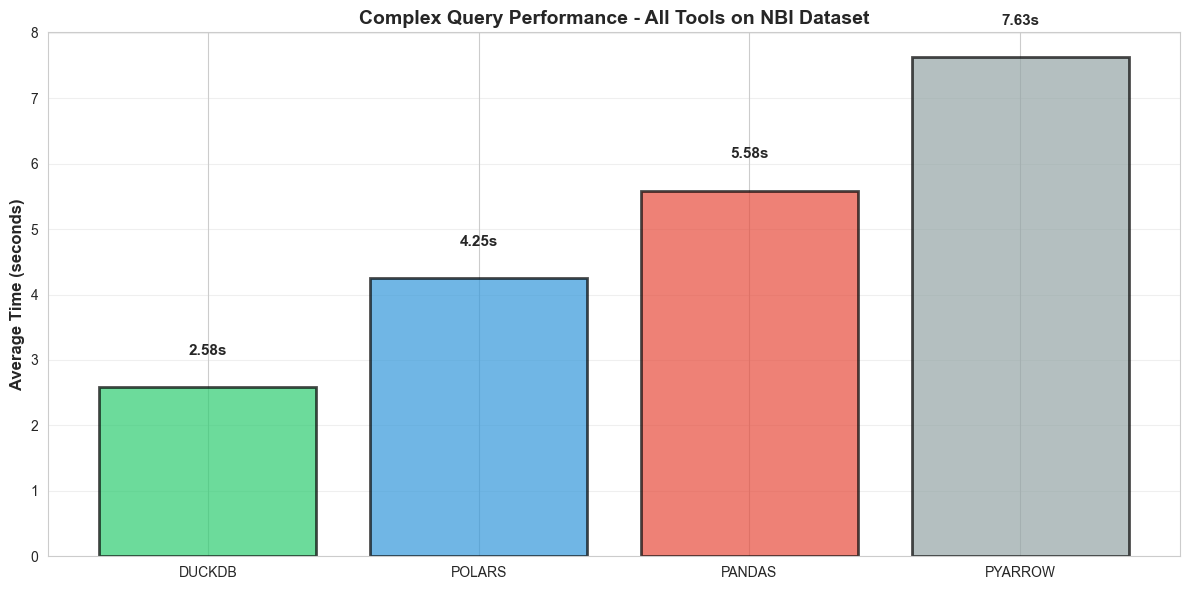

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))

tool_names = list(summary_df['Tool'])
avg_times = list(summary_df['Average Time (s)'])
colors = ['#2ecc71' if i == 0 else '#3498db' if i == 1 else '#e74c3c' if i == 2 else '#95a5a6' for i in range(len(tool_names))]

ax.bar(tool_names, avg_times, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Average Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Complex Query Performance - All Tools on NBI Dataset', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# \n(12 columns, 1,728 files, multi-level aggregation)

# Add value labels
for i, (tool, time) in enumerate(zip(tool_names, avg_times)):
    ax.text(i, time + 0.5, f'{time:.2f}s', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Visualization 2: Query-by-Query Comparison

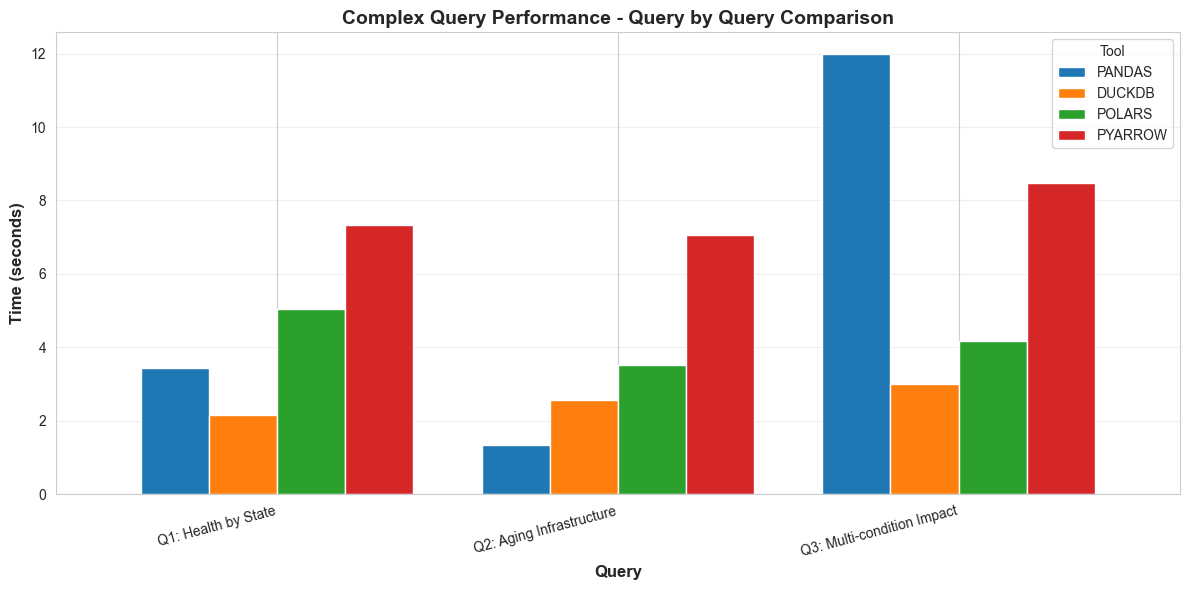

In [24]:
# Convert to numeric for plotting
plot_df = comparison_df.copy()
for col in plot_df.columns:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

fig, ax = plt.subplots(figsize=(12, 6))
plot_df.plot(kind='bar', ax=ax, width=0.8, align='center')
ax.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax.set_xlabel('Query', fontsize=12, fontweight='bold')
ax.set_title('Complex Query Performance - Query by Query Comparison', fontsize=14, fontweight='bold')
ax.legend(title='Tool', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## Visualization 3: Speedup Factor (vs Pandas)

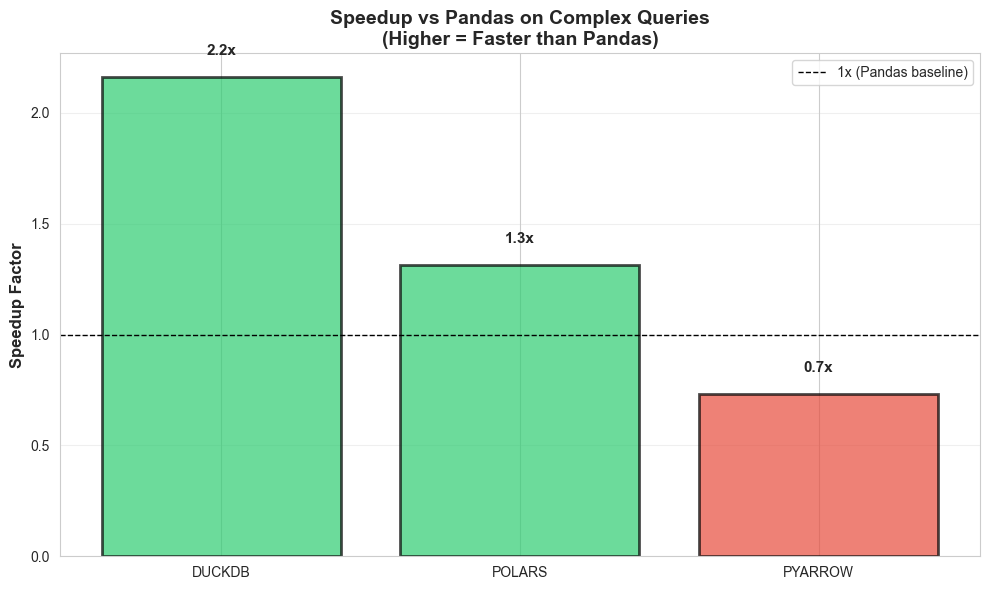

In [25]:
# Calculate speedup vs Pandas
speedup_data = {}
for tool in summary_df['Tool']:
    if tool != 'PANDAS':
        pandas_time = summary_df[summary_df['Tool'] == 'PANDAS']['Average Time (s)'].values[0]
        tool_time = summary_df[summary_df['Tool'] == tool]['Average Time (s)'].values[0]
        speedup = pandas_time / tool_time
        speedup_data[tool] = speedup

fig, ax = plt.subplots(figsize=(10, 6))
tools = list(speedup_data.keys())
speeds = list(speedup_data.values())
colors = ['#2ecc71' if s > 1 else '#e74c3c' for s in speeds]

ax.bar(tools, speeds, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.axhline(y=1, color='black', linestyle='--', linewidth=1, label='1x (Pandas baseline)')
ax.set_ylabel('Speedup Factor', fontsize=12, fontweight='bold')
ax.set_title('Speedup vs Pandas on Complex Queries\n(Higher = Faster than Pandas)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for tool, speed in speedup_data.items():
    ax.text(tools.index(tool), speed + 0.1, f'{speed:.1f}x', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Key Findings

### Simple vs Complex Query Performance

**Simple Query (1 column):**
- Pandas: 0.547s âœ… (WINNER)
- DuckDB: 1.213s (2.2x slower)
- Polars: 4.315s
- PyArrow: 22.904s

**Complex Query (12 columns, multi-level):**
- See above results

### Analysis

This demonstrates the **fundamental principle of database optimization**:

```
Simple Queries â†’ Use simple tools (Pandas fastest)
Complex Queries â†’ Use optimized tools (DuckDB/Polars excel)
```

**Why DuckDB is Now Better:**
1. **Column Pruning**: Only loads needed columns (vs Pandas loading all)
2. **Predicate Pushdown**: Filters before loading (vs Pandas filtering after)
3. **Vectorized Execution**: C++ operations (vs Pandas Python loops)
4. **Query Optimization**: Plans optimal execution strategy

**Why Pandas Was Better on Simple Queries:**
1. No optimization overhead
2. Direct in-memory operations
3. Simple query doesn't benefit from optimization